# QUESTION 1

## Imports

In [2]:
pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 693.9 kB/s  0:01:43m0:00:0100:04
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install torch-summary

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 611.7 kB/s  0:00:02ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.2/737.2 kB 487.5 kB/s  0:00:01m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchaudio]2 [torchaudio]
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
import torch
from torchsummary import summary
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_regression, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In this Exercise, you're going to train a neural network using the [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist). Fashion-MNIST is a set of 28 x 28 pixel greyscale images of clothes.

Some of you may have worked with this dataset before, it's a classic one. This dataset is ideal for your first PyTorch exercise. Below is a sample of some of the images in the dataset. We have 10 classes in the dataset: T-shirt/tops, Trousers, Pullovers, Dresses, Coats, Sandals, Shirts, Sneakers, Bags, and Ankle Boots.

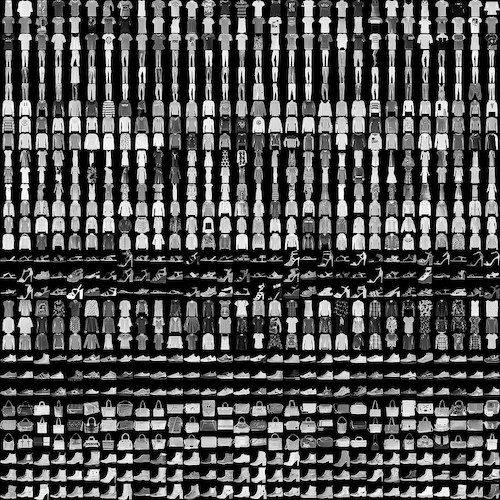

The goal of this question is to develop a network that can correctly predict a given image of "fashion" into one of the 10 classes. This is a multi-class classification task, our model should spit out 10 probabilities for a given image, one probability for each class. Ideally, the class our model predicts with maximum probability is the correct one.

The below cell will download and load in the Fashion-MNIST data for you. Note the following:

- Think of images as `ndarrays` of data, in the case of grayscale images like we have here, each pixel has a value between 0 and 1 indicating how "bright" that pixel is. So each image here is just a 28 x 28 `ndarray` with values ranging from 0 to 1 (when we get to colour images, it's exactly the same, except each pixel has 3 values, one for each of the colour channels Red, Blue, Green. If we had colour images here our array would be 28 x 28 x 3).

- `transform`: applies some transformations to the images. Here we are converting the data to tensors.

- `torch.utils.data.DataLoader`: these are _data loaders_. Think of them as generators. During training/testing, we can easily query them for a batch of data of size `BATCH_SIZE`.

The following cell might give you a warning, but no need to worry:

In [8]:
BATCH_SIZE = 64

# Define a transform to normalize the data, which usually helps with training
transform = transforms.Compose([transforms.ToTensor()])

# Download data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)

# Create data loaders (these are just generators that will give us `batch_size` samples as a time)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)

# Class labels
class_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

100%|██████████| 26.4M/26.4M [00:29<00:00, 911kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 110kB/s]
100%|██████████| 4.42M/4.42M [00:07<00:00, 604kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


Let's plot a random image (run this cell as many times as you like to see different images):

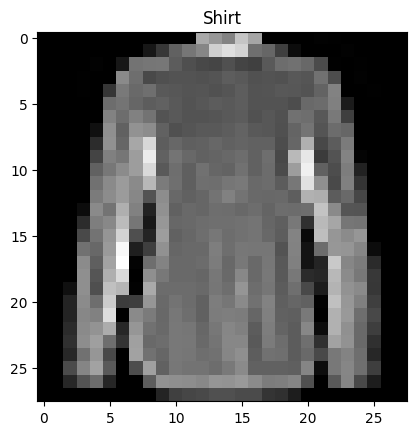

In [9]:
image, label = next(iter(trainloader))  # Get a random batch of 64 images
i = np.random.randint(0, 64)            # Choose one image at random
plt.imshow(image[i, 0], cmap='gray')    # Plot
plt.title(class_labels[label[i]]);

## 1.1

{accuracy: 3}

Notice in the plot above that our image is 28 x 28 pixels. How do we feed this into a neural network? Well we can flatten it out into a vector of 784 elements (28 x 28 = 784) and create 784 input nodes. We'll do this later on. For now, all I want you to do is create a new class for our PyTorch neural network model defining a classifier with the following architecture:

- hidden layer that goes from `input_size` -> 256 nodes

- ReLU activation function
- hidden layer that goes from 256 nodes -> 128 nodes
- ReLU activation function
- hidden layer that goes from 128 nodes -> 64 nodes
- ReLU activation function
- output layer that goes from 64 nodes -> `output_size` nodes

Following is some starter code to fill in.

**Note:** When we create our model in a later exercise we will specify `input_size=784` and `output_size=10`. The `784` is the flattened 28 x 28 image and the output size of 10 is so that we have one node for each item of clothing (remember we have 10 classes), and each node will contain the probability of that item of clothing being the one in a particular input image.

In [10]:
class Classifier(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.main = nn.Sequential(
            # First hidden layer: 784 -> 256
            nn.Linear(input_size, 256),
            nn.ReLU(),
            
            # Second hidden layer: 256 -> 128
            nn.Linear(256, 128),
            nn.ReLU(),
            
            # Third hidden layer: 128 -> 64
            nn.Linear(128, 64),
            nn.ReLU(),
            
            # Output layer: 64 -> 10 (output_size)
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        out = self.main(x)
        return out

## 1.2

{accuracy: 2}

If your model has `input_size=784` and `output_size=10`, how many parameters does your model have? Write your manual calculations, and verify your result using `torchsummary.summary()`.

In [ ]:
Layer 1: 784 input → 256 hidden
Weights: 784×256=200,704
Biases: 256
Layer Total: 200,960
Layer 2: 256 hidden → 128 hidden
Weights: 256×128=32,768
Biases: 128
Layer Total: 32,896
Layer 3: 128 hidden → 64 hidden
Weights: 128×64=8,192
Biases: 64
Layer Total: 8,256
Layer 4 (Output): 64 hidden → 10 output
Weights: 64×10=640
Biases: 10
Layer Total: 650
Grand Total: 200,960+32,896+8,256+650=242,762


In [11]:
from torchsummary import summary

# Instantiate the model with your parameters
model = Classifier(input_size=784, output_size=10)

# Provide input shape as (Channels, Height, Width) or (Flat_Size,)
# Since we are flattening in the forward pass, let's pass the image shape
summary(model, (1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 10]                  --
|    └─Linear: 2-1                       [-1, 256]                 200,960
|    └─ReLU: 2-2                         [-1, 256]                 --
|    └─Linear: 2-3                       [-1, 128]                 32,896
|    └─ReLU: 2-4                         [-1, 128]                 --
|    └─Linear: 2-5                       [-1, 64]                  8,256
|    └─ReLU: 2-6                         [-1, 64]                  --
|    └─Linear: 2-7                       [-1, 10]                  650
Total params: 242,762
Trainable params: 242,762
Non-trainable params: 0
Total mult-adds (M): 0.48
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.93
Estimated Total Size (MB): 0.93


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 10]                  --
|    └─Linear: 2-1                       [-1, 256]                 200,960
|    └─ReLU: 2-2                         [-1, 256]                 --
|    └─Linear: 2-3                       [-1, 128]                 32,896
|    └─ReLU: 2-4                         [-1, 128]                 --
|    └─Linear: 2-5                       [-1, 64]                  8,256
|    └─ReLU: 2-6                         [-1, 64]                  --
|    └─Linear: 2-7                       [-1, 10]                  650
Total params: 242,762
Trainable params: 242,762
Non-trainable params: 0
Total mult-adds (M): 0.48
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.93
Estimated Total Size (MB): 0.93

## 1.3

{accuracy: 3}

We haven't trained yet, but let's test out your network. The below function will help you plot your network's predictions for a particular image using `matplotlib`, run it:

In [12]:
def plot_prediction(image, label, predictions):
    """Plot network predictions with matplotlib."""

    fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2)  # Plot
    ax1.imshow(image[0], cmap='gray')
    ax1.axis('off')
    ax1.set_title(class_labels[label])
    ax2.barh(np.arange(10), predictions.data.numpy().squeeze())
    ax2.set_title("Predictions")
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(class_labels)
    ax2.set_xlim(0, 1)
    plt.tight_layout();

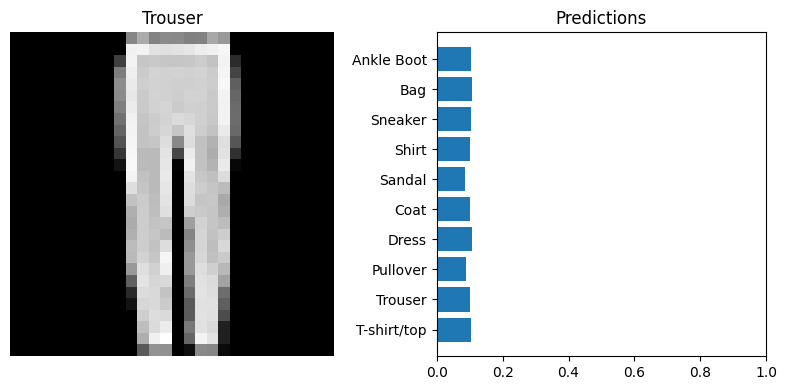

In [13]:
# ## Uncomment and run the following

model = Classifier(input_size=784, output_size=10)

# # Test on training images (run as many times as you like!)
image, label = next(iter(trainloader))        # Get a random batch of 64 images
predictions = model(image[0].reshape(1, -1))  # Get first image, flatten to shape (1, 784) and predict it
predictions = nn.Softmax(dim=1)(predictions)  # Coerce predictions to probabilities using Softmax()
plot_prediction(image[0], label[0], predictions)

Those predictions look probably pretty bad, because the model is not trained yet.

Below is a training function similar to what we saw in lectures. The only difference is that when I'm creating `y_hat` (model predictions), I'm reshaping my `X` data from `(batch_size, 1, 28, 28)` to `(batch_size, 784)`, so that we can feed it into our network. `X.shape[0]` is the batch size, and the `-1` just says _flatten remaining dimensions into a single dimension_.

In [14]:
def trainer(model, criterion, optimizer, dataloader, epochs=5, verbose=True):
    """Simple training wrapper for PyTorch network."""

    for epoch in range(epochs):
        losses = 0
        for X, y in dataloader:
            optimizer.zero_grad()       # Clear gradients w.r.t. parameters
            y_hat = model(X.reshape(X.shape[0], -1))  # Reshape data to (batch_size, 784) and forward pass to get output
            loss = criterion(y_hat, y)  # Calculate loss
            loss.backward()             # Getting gradients w.r.t. parameters
            optimizer.step()            # Update parameters
            losses += loss.item()       # Add loss for this batch to running total

        if verbose:
            print(f"epoch: {epoch + 1}, loss: {losses / len(dataloader):.4f}")

Now define an appropriate `criterion` and `optimizer` to train your model with.

- We are doing multi-class classification here, what loss function do we use for this case?

- Use any optimizer you like, but I recommend Adam

I already created the dataloader `trainloader` for you at the start of this exercise. Pass all these things to `trainer()` to train your model. Remember that it may take a few minutes to complete.

In [15]:
# YOUR SOLUTION HERE
# 1. Define the model
model = Classifier(input_size=784, output_size=10)

# 2. Define the loss function (Criterion)
criterion = nn.CrossEntropyLoss()

# 3. Define the optimizer
# lr=0.003 is usually a good starting point for Adam on FashionMNIST
optimizer = optim.Adam(model.parameters(), lr=0.003)



In [16]:
def trainer(model, trainloader, criterion, optimizer, epochs=5):
    for e in range(epochs):
        running_loss = 0
        for images, labels in trainloader:
            # Flatten images: (64, 1, 28, 28) -> (64, 784)
            images = images.view(images.shape[0], -1)
        
            # 1. Clear the gradients
            optimizer.zero_grad()
            
            # 2. Forward pass
            output = model(images)
            
            # 3. Calculate loss
            loss = criterion(output, labels)
            
            # 4. Backward pass (Backpropagation)
            loss.backward()
            
            # 5. Update weights
            optimizer.step()
            
            running_loss += loss.item()
        else:
            print(f"Epoch {e+1} - Training loss: {running_loss/len(trainloader)}")

# Execute the training
trainer(model, trainloader, criterion, optimizer, epochs=5)

Epoch 1 - Training loss: 0.5120372314855997
Epoch 2 - Training loss: 0.3785888557590401
Epoch 3 - Training loss: 0.34421526043336276
Epoch 4 - Training loss: 0.31867520133061195
Epoch 5 - Training loss: 0.30518717259994704


## 1.4

{reasoning: 1}
Test out your newly trained network on the training data:

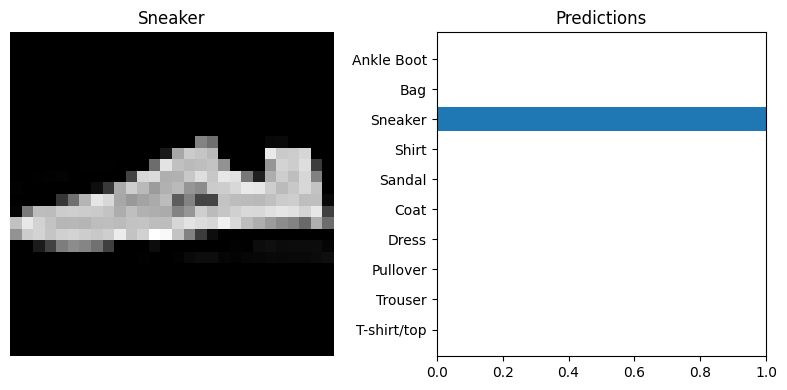

In [17]:
# ## Uncomment andrunthe following
# # Test model on training images (run as many times as you like!)
image, label = next(iter(trainloader))        # Get a random batch of 64 images

predictions = model(image[0].view(1, -1))     # Get first image, flatten to shape (1, 784) and predict it
predictions = nn.Softmax(dim=1)(predictions)  # Coerce predictions to probabilities using Softmax()
plot_prediction(image[0], label[0], predictions)

And test it out on the test data:

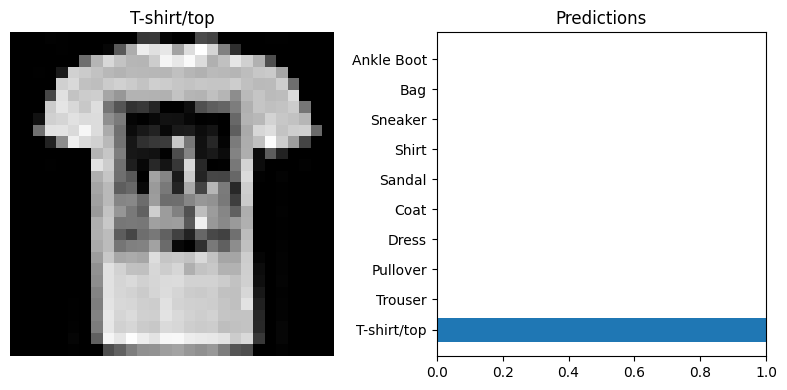

In [18]:
# ## Uncomment andrunthe following
# # Test model on testing images (run as many times as you like!)
image, label = next(iter(testloader))        # Get a random batch of 64 images
predictions = model(image[0].view(1, -1))     # Get first image, flatten to shape (1, 784) and predict it
predictions = nn.Softmax(dim=1)(predictions)  # Coerce predictions to probabilities using Softmax()
plot_prediction(image[0], label[0], predictions)

Hopefully your predictions look good. You just created your first neural network classifier!

**Now comes the question for you:** In this exercise we used a `BATCH_SIZE = 64`. Describe how choosing a small vs. large batch size affects the convergence of the optimization algorithm, as well as hardware requirements.

Smaller batch carriers more noise however, they are more computational efficent. Some projects would be a primal project for this.

larger batrch is more defined and more smooth graident. It is more computaional intensive. However, not the larger batch size, the better the outcome. Sometimes, it will get stuck at the local minima.

# QUESTION 2

### Question:

Consider a dataset represented as the following matrix, where each row corresponds to a sample and each column corresponds to a feature:

$$
\
X = \begin{bmatrix}
1 & 2 \\
2 & 3 \\
3 & 4 \\
4 & 5
\end{bmatrix}
$$


You are asked to apply three different kernels on this dataset: linear kernel, polynomial kernel (degree 2), and radial basis function (RBF) kernel. Answer the following:

1. Compute the kernel matrix for the **linear kernel** using $$\( K(x_i, x_j) = x_i^T x_j) \$$

2. Compute the kernel matrix for the **polynomial kernel (degree 2)** using $$\( K(x_i, x_j) = (x_i^T x_j + 1)^2) \$$

3. Describe the behavior of the **RBF kernel** in terms of feature space transformation. You don't need to compute it explicitly but explain how it handles data.


The resulting matrix is:
$$K_{linear} = \
5 & 8 & 11 & 14 \
8 & 13 & 18 & 23 \
11 & 18 & 25 & 32 \
14 & 23 & 32 & 41

The resulting matrix is:
$$K_{poly} = \
36 & 81 & 144 & 225 \
81 & 196 & 361 & 576 \
144 & 361 & 676 & 1089 \
225 & 576 & 1089 & 1764

The RBF has infinate dimensitonality, it measures promixity, and can handle non-linearity


# QUESTION 3

### Question:

Consider a feedforward neural network with the following characteristics:
- The input feature vector is \( x = [2, -1, 3, 0] \) with 4 features.
- The network has one hidden layer with 3 neurons.
- The activation function for the hidden layer is the ReLU function.
- The output layer has 1 neuron with a sigmoid activation function, representing the probability of the positive class.
- The weights and biases are initialized as follows:
 - For the hidden layer:  
   $$  W^{(1)} = \begin{bmatrix} 0.2 & -0.5 & 0.1 & 0.4 \\ -0.3 & 0.8 & 0.5 & -0.2 \\ 0.7 & -0.4 & 0.2 & 0.1 \end{bmatrix}, \quad b^{(1)} = \begin{bmatrix} 0.1 \\ 0.2 \\ 0.3 \end{bmatrix}  $$
  - For the output layer:  
   $$  W^{(2)} = \begin{bmatrix} 0.5 & -0.6 & 0.3 \end{bmatrix}, \quad b^{(2)} = 0.2 $$


Answer the following questions:

1. **Forward Pass:**
   a. Compute the activations for the hidden layer and the final output of the network. Show all intermediate steps.
   
2. **Backward Pass (Gradient Calculation):**
   a. Assume the true label \( y = 1 \), and the binary cross-entropy loss function is:  
      $\[
      L = -(y \log(f) + (1 - y) \log(1 - f))
      \]$
      Compute the gradient of the loss function \( L \) with respect to the weights of the output layer. Show all steps.
   
3. **Weight Update:**
   a. Using a learning rate of $ \alpha = 0.01 $, write down the gradient descent update rule for the output layer weights. Compute the updated weights after one iteration.

4. **Activation Function Impact:**
   a. If we were to replace the ReLU activation in the hidden layer with a sigmoid activation, how would this change the forward pass? Provide the new expressions but no need to compute the output.

f= 
1+e 
−1.48
 
1
​	
 ≈ 
1+0.2276
1
​	
 ≈0.8147

 Error Term = −0.1853, Gradient∇ 
W 
(2)
 
​	
 L=−0.1853⋅[1.3,0.3,2.7]=[−0.24089,−0.05559,−0.50031]

 Weight UpdateW 
(2)
 =[0.50241,−0.59944,0.30500]

 If we replace ReLU with Sigmoid, the forward pass changes in the "squashing" of the hidden layer values.

New Expression for Hidden Activations:

a 
(1)
 =σ(z 
(1)
 )= 
1+e 
−(W 
(1)
 x+b 
(1)
 )
 
1
​

# QUESTION 4

Adam (adaptive moment estimation) is an optimization algorithm that we'll be using a lot for the rest of the course. [Here](https://arxiv.org/abs/1412.6980)'s the original paper that proposed the algorithm. It is essentially a fancier version of SGD. Without getting too technical, Adam really adds two additional features to SGD:

1. Momentum: which uses past gradients to help improve convergence speed, reduce noise in the path to the minimum, and avoid local minima.

2. Per-parameter learning rate: a learning rate is maintained and adapted for each parameter as iterations of optimization proceed.

Recommended: [read this article](https://ruder.io/optimizing-gradient-descent/index.html) to learn more, but Adam boils down to the following weight updating procedure:

$$\mathbf{w}_{t+1} = \mathbf{w}_{t} - \frac{\alpha}{\sqrt{\hat{v}_{t}} + \epsilon} \hat{m}_{t}$$

The various components required for that equation:

$$\begin{align}
\hat{m}_{t} &= \frac{m_{t}}{1 - \beta_{1}^{t}}\\
\hat{v}_{t} &= \frac{v_{t}}{1 - \beta_{2}^{t}}
\end{align}$$

$$\begin{align}
m_{t} &= \beta_{1} m_{t-1} + (1 - \beta_{1}) g_{t}\\
v_{t} &= \beta_{2} v_{t-1} + (1 - \beta_{2}) g_{t}^{2}
\end{align}$$

Where:

- $t$ is the iteration of optimization, it increments up by one each time you update $\mathbf{w}$. Note that in the equation for $\hat{m}_{t}$ and $\hat{v}_{t}$, $\beta_{1}$ and $\beta_{2}$ are raised to the power of $t$.

- $g_{t}$ is the gradient of the loss function w.r.t to the parameters $w$.
- $m_{t}$ is known as the first moment (the mean) of the gradients. In the first iteration, initialize $m_{-1}$ to 0 to get the solution started.
- $v_{t}$ is known as the second moment (the uncentered variance) of the gradients. In the first iteration, initialize $v_{-1}$ to 0 to get the solution started.
- $\alpha$ is the learning rate. 0.1 is a good start.
- $\epsilon$ is just a term to prevent division by zero. Default: $10^{-8}$.
- $\beta_{1}$ is a hyperparameter that controls the influence of past gradients on subsequent updates. Default: $0.9$.
- $\beta_{2}$ is a hyperparameter that controls the influence of past gradients on subsequent updates. Default: $0.999$.

Here's a function with both local and global minima. We know in advance that the global minimum occurs at $w_{opt}=4$. I want you to find this value using Adam optimization and starting at $w \neq w_{opt}$. I've provided you the function (`f()`), the MSE loss w.r.t this function (`loss()`), and the gradient of the loss (`loss_grad()`). Run the cell below:

#### Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt

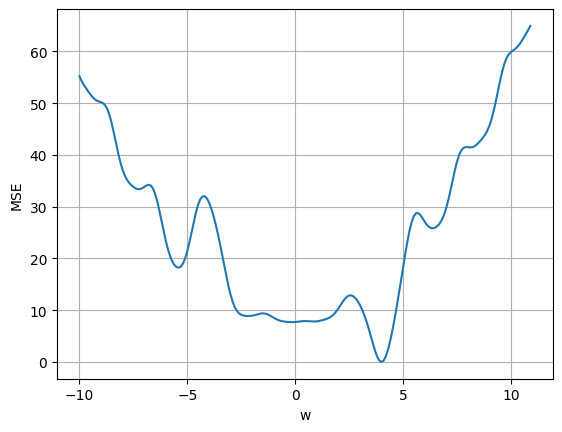

In [20]:
def f(w, X):
    """Squiggly function"""
    return w * np.cos(w * X)

def loss(w, X, y):
    """MSE loss."""
    return np.mean((f(w, X) - y) ** 2)

def loss_grad(w, X, y):
    """Gradient of MSE."""
    t = np.cos(w * X) - w * X * np.sin(w * X)
    return np.mean((f(w, X) - y) * t)

w_opt = 4
X = np.arange(-3, 3, 0.1)
y = f(w_opt, X)
l = [loss(w, X, y) for w in np.arange(-10, 11, 0.1)]

plt.plot(np.arange(-10, 11, 0.1), l)
plt.xlabel("w")
plt.ylabel("MSE")
plt.grid(True);

Your task here is to implement Adam from scratch. Then use it to find $w_{opt}$ for the above function. Some code has been provided below that you should run when you're ready. Note that:

-  A default of 100 epochs is specified. We have a *tiny* dataset here of 60 samples so this is nothing substantial. Feel free to add more epochs if you wish.

- You can start with the default values for the various Adam terms I give in the equations above.
- You *may* need to play around with the hyperparameter $\alpha$ to get to the minimum (I've given a default of 0.3 in the starter code below. I didn't need to change this value in my solution). You can leave $\beta_{1}$, $\beta_{2}$ as is - Often we don't tune those ones and I didn't in my solution, but you can tune them if you want.
- Adam uses batches just like SGD, so my solution has the ability to accept a `batch_size` argument. But you don't have to implement this functionality and I didn't include that argument in the starter code below. So feel free to just use all the data each iteration for simplicity like vanilla GD would do. If you're feeling adventurous, no one should stop you from throwing in a `batch_size` argument.

The pedagogical goal here is to get you to implement Adam and play around with it to see how it can **jump over** local minima.

_Points:_ 2

In [21]:
def Adam(X, y, w0, loss, loss_grad, n_epochs=100, batch_size=1, alpha=0.3, beta1=0.9, beta2=0.999, eta=10e-8, verbose=False):
    # BEGIN SOLUTION
    w = w0
    m = 0  # First moment
    v = 0  # Second moment
    t = 0  # Time step counter
    
    w_history = [w]
    loss_history = [loss(w, X, y)]

    for epoch in range(n_epochs):
        t += 1 # Increment time step
        
        # Calculate gradient for the current weight
        # (Using all data X, y as per the simple case, or a batch if implemented)
        grad = loss_grad(w, X, y)
        
        # 1. Update biased first moment estimate (Momentum)
        m = beta1 * m + (1 - beta1) * grad
        
        # 2. Update biased second raw moment estimate (RMSProp logic)
        v = beta2 * v + (1 - beta2) * (grad**2)
        
        # 3. Compute bias-corrected first moment estimate
        # This compensates for m being initialized at 0
        m_hat = m / (1 - beta1**t)
        
        # 4. Compute bias-corrected second raw moment estimate
        v_hat = v / (1 - beta2**t)
        
        # 5. Update weights
        # We scale the learning rate by the inverse of the square root of v_hat
        w = w - alpha * m_hat / (np.sqrt(v_hat) + eta)
        
        # record history
        current_loss = loss(w, X, y)
        w_history.append(w)
        loss_history.append(current_loss)

        if verbose and epoch % 10 == 0:
            print(f"Epoch {epoch}: w = {w:.4f}, Loss = {current_loss:.4f}")

    return w, w_history, loss_history
    # END SOLUTION

In [22]:
w0 = np.array([9])
w = Adam(X, y, w0, loss, loss_grad)
print(w)  # Should be close to 4

(array([3.98756737]), [array([9]), array([8.70000001]), array([8.42205498]), array([8.16051809]), array([7.9405322]), array([7.75630593]), array([7.55555079]), array([7.32375609]), array([7.07479259]), array([6.80969189]), array([6.543463]), array([6.29286812]), array([6.07369368]), array([5.90342342]), array([5.78106049]), array([5.69122376]), array([5.61659035]), array([5.54074626]), array([5.44715127]), array([5.31951728]), array([5.14798628]), array([4.93531261]), array([4.69073419]), array([4.42352151]), array([4.1435315]), array([3.87073638]), array([3.64064909]), array([3.47196005]), array([3.35963305]), array([3.29371877]), array([3.26632237]), array([3.27212988]), array([3.30785445]), array([3.37168164]), array([3.46266291]), array([3.57970452]), array([3.71974197]), array([3.87513879]), array([4.03159063]), array([4.16978923]), array([4.2726762]), array([4.33151798]), array([4.34546564]), array([4.31856222]), array([4.25771937]), array([4.17203975]), array([4.07283069]), arra

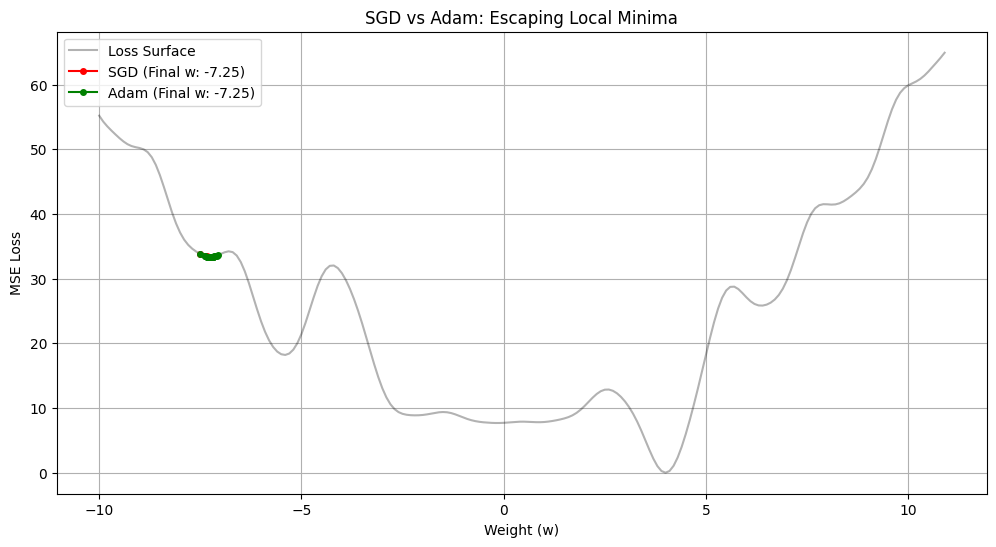

In [23]:
def sgd(X, y, w0, loss, loss_grad, n_epochs=100, alpha=0.1):
    w = w0
    w_history = [w]
    loss_history = [loss(w, X, y)]
    
    for _ in range(n_epochs):
        grad = loss_grad(w, X, y)
        w = w - alpha * grad
        w_history.append(w)
        loss_history.append(loss(w, X, y))
    return w, w_history, loss_history

# Initial weight (Start in a local minimum "trap" at -7.5)
w_start = -7.5

# Run SGD
w_sgd, w_hist_sgd, l_hist_sgd = sgd(X, y, w_start, loss, loss_grad, n_epochs=100, alpha=0.1)

# Run Adam (using your implemented function)
w_adam, w_hist_adam, l_hist_adam = Adam(X, y, w_start, loss, loss_grad, n_epochs=100, alpha=0.3)

# Plotting the comparison
plt.figure(figsize=(12, 6))
w_range = np.arange(-10, 11, 0.1)
plt.plot(w_range, [loss(w, X, y) for w in w_range], 'k-', alpha=0.3, label='Loss Surface')

# Plot SGD path
plt.plot(w_hist_sgd, l_hist_sgd, 'ro-', markersize=4, label=f'SGD (Final w: {w_sgd:.2f})')

# Plot Adam path
plt.plot(w_hist_adam, l_hist_adam, 'go-', markersize=4, label=f'Adam (Final w: {w_adam:.2f})')

plt.title("SGD vs Adam: Escaping Local Minima")
plt.xlabel("Weight (w)")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()